In [ ]:
import os

# Numpy is a math lib
import numpy as np

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

# Set seed for experimental reproducibility (Change if you want different outcomes)
seed = 1 
np.random.seed(seed)

CIRCLES_OS_PATH = 'circles/'
RECTANGLES_OS_PATH = 'rectangles/'
TRIANGLES_OS_PATH = 'triangles/'

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


## Create Shapes (Data Augmentation)

## Helpers

In the below cell we define some helper functions for creating the dataset.

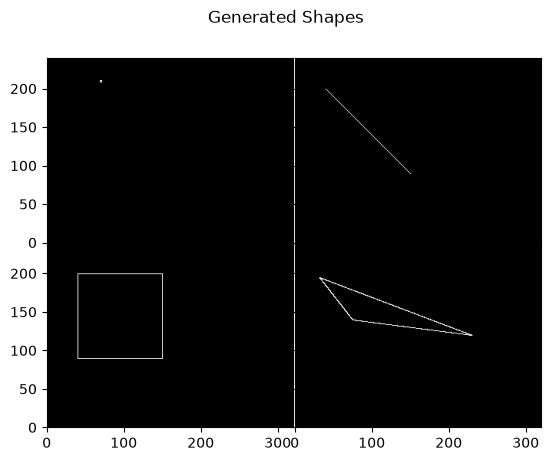

In [155]:
# Amount of datapoints in set (SAMPLES = 1000 => (1000 Circles, 1000 Rectangles, 1000 Triangles) = 3000 datapoints)
SAMPLES = 1000
WIDTH = 240 # Change as needed
HEIGHT = 320 # Changed as needed

class Point:
    x = 0
    y = 0
    def __init__(self, x, y):
        self.x = x
        self.y = y

screen = np.zeros((WIDTH, HEIGHT), dtype=np.int8)
np.set_printoptions(threshold=np.inf)

def clear_screen():
    global screen
    screen = np.zeros((WIDTH, HEIGHT), dtype=np.int8)

def show_screen(axs):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,320,0,240))


def linear_interpolation(start, end, t):
    return (1-t)*start + t*end

def generate_circle(point, radius, file_name):
    current_x = math.cos(0)
    current_y = math.sin(0)
    angle = 0
    while angle <= (math.pi*2):
        index_x = round((current_x*radius)+point.x)
        index_y = round((current_y*radius)+point.y)
        if index_x < WIDTH and index_x >= 0 and index_y < HEIGHT and index_y >= 0:     
            screen[index_x][index_y] = 1
        current_x = math.cos(angle)
        current_y = math.sin(angle)
        angle += 0.001
    
    with open(os.path.join(CIRCLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(CIRCLES_OS_PATH, file_name), screen, fmt="%d")        

def generate_line(start_point, end_point):
    t = 0

    while t <= 1:
        index_x = round(linear_interpolation(start_point.x, end_point.x, t))
        index_y = round(linear_interpolation(start_point.y, end_point.y, t))
        if index_x < WIDTH and index_x >= 0 and index_y < HEIGHT and index_y >= 0: 
            screen[index_x][index_y] = 1
        t += 0.001

def generate_rectangle(top_left, bottom_right, file_name):
    # Top Line
    generate_line(top_left, Point(bottom_right.x, top_left.y))
    # Bottom Line
    generate_line(Point(top_left.x, bottom_right.y), bottom_right)
    #Right Line
    generate_line(top_left, Point(top_left.x, bottom_right.y))
    #Left Line
    generate_line(Point(bottom_right.x, top_left.y), bottom_right)
    with open(os.path.join(RECTANGLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(RECTANGLES_OS_PATH, file_name), screen, fmt="%d")  

def generate_triangle(vertex_1, vertex_2, vertex_3, file_name):
    generate_line(vertex_1, vertex_2)
    generate_line(vertex_2, vertex_3)
    generate_line(vertex_3, vertex_1)
    with open(os.path.join(TRIANGLES_OS_PATH, file_name), 'w') as fp:
        pass

    np.savetxt(os.path.join(TRIANGLES_OS_PATH, file_name), screen, fmt="%d")  

fig = plt.figure()
gs = fig.add_gridspec(2,2, hspace=0,wspace=0)
(axs1,axs2),(axs3,axs4) = gs.subplots(sharex=True, sharey=True)
fig.suptitle('Generated Shapes')

generate_circle(Point(30, 70),1,'test.cir')
show_screen(axs1)

clear_screen()

generate_line(Point(40,40),Point(150,150))
show_screen(axs2)

clear_screen()

generate_rectangle(Point(40,40),Point(150,150), 'test.rec')
show_screen(axs3)

clear_screen()

generate_triangle(Point(45,32),Point(120,230),Point(100,75), 'test.tri')
show_screen(axs4)

# Generate Dataset

In [ ]:
def generate_circle_samples():
    for i in range(SAMPLES):
        pos_x = np.random.random() * WIDTH
        pos_y = np.random.random() * HEIGHT
        r = (np.random.random() * (WIDTH/2))+1 
        generate_circle(Point(pos_x,pos_y), r, F'circle-{i}.cir')
        print(F'Finished Generating {i}:th Circle')
        clear_screen()

def generate_rectangle_samples():
    #fig = plt.figure()
    #gs = fig.add_gridspec(2, 5, hspace=0, wspace=0)
    #axs = gs.subplots()
    for i in range(SAMPLES):
        pos1_x = (np.random.random() * WIDTH) + ((np.random.random() * 100) - 50)
        pos1_y = (np.random.random() * HEIGHT) + ((np.random.random() * 100) - 50)
        pos2_x = (np.random.random() * WIDTH) + ((np.random.random() * 100) - 50)
        pos2_y = (np.random.random() * HEIGHT) + ((np.random.random() * 100) - 50)

        if (pos1_x >= WIDTH and pos2_x >= WIDTH) or (pos1_y >= HEIGHT and pos2_y >= HEIGHT) or (pos1_x < 0 and pos2_x < 0) or (pos1_y < 0 and pos2_y < 0):
            pos1_x = (np.random.random() * WIDTH)
            pos1_y = (np.random.random() * HEIGHT)
            pos2_x = (np.random.random() * WIDTH)
            pos2_y = (np.random.random() * HEIGHT)

        generate_rectangle(Point(pos1_x, pos1_y), Point(pos2_x, pos2_y), F'rectangle-{i}.rec')
        print(F'Finished Generating {i}:th Rectangle')
        #if i < 5:
        #    show_screen(axs[0][i])
        #else:
        #    show_screen(axs[1][i-5])
        clear_screen()


def generate_triangle_samples():
    for i in range(SAMPLES):
        pos1_x = (np.random.random() * WIDTH) + ((np.random.random() * 100) - 50)
        pos1_y = (np.random.random() * HEIGHT) + ((np.random.random() * 100) - 50)
        pos2_x = (np.random.random() * WIDTH) + ((np.random.random() * 100) - 50)
        pos2_y = (np.random.random() * HEIGHT) + ((np.random.random() * 100) - 50)
        pos3_x = (np.random.random() * WIDTH) + ((np.random.random() * 100) - 50)
        pos3_y = (np.random.random() * HEIGHT) + ((np.random.random() * 100) - 50)

        if (pos1_x >= WIDTH and pos2_x >= WIDTH and pos3_x >= WIDTH) or (pos1_y >= HEIGHT and pos2_y >= HEIGHT and pos3_y >= HEIGHT) or (pos1_x < 0 and pos2_x < 0 and pos3_x < 0) or (pos1_y < 0 and pos2_y < 0 and pos3_y < 0):
            pos1_x = (np.random.random() * WIDTH)
            pos1_y = (np.random.random() * HEIGHT)
            pos2_x = (np.random.random() * WIDTH)
            pos2_y = (np.random.random() * HEIGHT)

        generate_triangle(Point(pos1_x, pos1_y), Point(pos2_x, pos2_y), Point(pos3_x, pos3_y), F'triangle-{i}.tri')
        print(F'Finished Generating {i}:th Triangle')
        clear_screen()


generate_circle_samples()
generate_rectangle_samples()
generate_triangle_samples()

Finished Generating 0:th Triangle
Finished Generating 1:th Triangle
Finished Generating 2:th Triangle
Finished Generating 3:th Triangle
Finished Generating 4:th Triangle
Finished Generating 5:th Triangle
Finished Generating 6:th Triangle
Finished Generating 7:th Triangle
Finished Generating 8:th Triangle
Finished Generating 9:th Triangle
Finished Generating 10:th Triangle
Finished Generating 11:th Triangle
Finished Generating 12:th Triangle
Finished Generating 13:th Triangle
Finished Generating 14:th Triangle
Finished Generating 15:th Triangle
Finished Generating 16:th Triangle
Finished Generating 17:th Triangle
Finished Generating 18:th Triangle
Finished Generating 19:th Triangle
Finished Generating 20:th Triangle
Finished Generating 21:th Triangle
Finished Generating 22:th Triangle
Finished Generating 23:th Triangle
Finished Generating 24:th Triangle
Finished Generating 25:th Triangle
Finished Generating 26:th Triangle
Finished Generating 27:th Triangle
Finished Generating 28:th Tria